# impulse buying analysis

the central question of this project: **do bad weather days trigger impulsive purchasing behavior?**

since we cant ask customers whether they felt impulsive, we look for behavioral fingerprints in the data. In this data set 96% of the customers were one-time customers so we can't check frequency. Had to come up with a alternative method. Impulsive weather driven purchases should show up as:
- a shift in product categories toward comfort and indoor items
- possibly different times of day or spend levels

at the end we translate this into segment-level marketing recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('cleaned/master.csv', parse_dates=['purchase_date'])
segments = pd.read_csv('cleaned/customers_clustered.csv')[['customer_id', 'segment']]
df = df.merge(segments, on='customer_id', how='left')

print('loaded:', df.shape)

loaded: (88675, 24)


## step 1: define bad weather

a day counts as 'bad weather' if it had significant rainfall (>5mm) OR was unusually cold for the time of year.

**a note on how we got here.** in notebook 04 we used absolute cold (below median temperature) for the hypothesis tests. that worked for showing *that* something was different on cold days, but partway through this analysis we realized 'cold' defined that way is mostly just 'winter'. buying a blanket on a cold winter day is seasonal, not impulsive, it's exactly what you'd expect. so the cold-vs-hot finding in notebook 04 was likely picking up seasonal shopping habits rather than impulse behavior.

what we actually want to capture is *unexpected* cold: a day that's much colder than typical for that month. those are the days that could plausibly catch people off guard and shift their mood / behavior. so for this notebook we switch to a temperature anomaly definition (each day's deviation from its monthly average), and flag days more than 3 C below the monthly norm as cold.

this is also the right framing for any production marketing system: an unexpectedly cold tuesday in october is a real event worth reacting to, while a cold tuesday in july is just july.

In [2]:
# temperature anomaly: how cold was this day compared to the month's average?
monthly_avg = df.groupby(df['purchase_date'].dt.month)['temp_mean_c'].transform('mean')
df['temp_anomaly'] = df['temp_mean_c'] - monthly_avg

df['bad_weather'] = (
    (df['precip_total_mm'] > 5) | (df['temp_anomaly'] < -3)
).astype(int)

print(f'bad weather orders: {df["bad_weather"].sum():,} ({df["bad_weather"].mean()*100:.1f}%)')
print(f'good weather orders: {(df["bad_weather"]==0).sum():,} ({(df["bad_weather"]==0).mean()*100:.1f}%)')
print(f'avg temp anomaly on bad weather days: {df.loc[df["bad_weather"]==1, "temp_anomaly"].mean():.2f} C')
print(f'avg temp anomaly on good weather days: {df.loc[df["bad_weather"]==0, "temp_anomaly"].mean():.2f} C')

bad weather orders: 26,385 (29.8%)
good weather orders: 62,290 (70.2%)
avg temp anomaly on bad weather days: -2.66 C
avg temp anomaly on good weather days: 1.12 C


## step 2: category shift analysis

this is the core of the impulse analysis. if bad weather genuinely changes what people buy, we should see certain categories becoming more popular and others becoming less popular.

we compute the market share of each category on bad vs good weather days, then look at the relative shift.

In [3]:
bad  = df[df['bad_weather'] == 1]
good = df[df['bad_weather'] == 0]

share_bad  = bad['main_category'].value_counts()  / len(bad)
share_good = good['main_category'].value_counts() / len(good)

# relative shift: how much more/less popular is each category in bad weather?
shift = ((share_bad - share_good) / share_good).dropna().sort_values(ascending=False)

# only keep categories with at least 100 total orders to avoid noise
big_enough = df['main_category'].value_counts()[df['main_category'].value_counts() >= 100].index
shift = shift[shift.index.isin(big_enough)]

print('categories most shifted by bad weather (top 10 each direction):')
print(pd.concat([shift.head(10), shift.tail(10)]).round(3).to_string())

categories most shifted by bad weather (top 10 each direction):
main_category
market_place                  0.188
home_appliances_2             0.156
fashion_shoes                 0.147
stationery                    0.143
signaling_and_security        0.137
air_conditioning              0.119
home_appliances               0.116
fixed_telephony               0.116
electronics                   0.110
construction_tools_lights     0.105
audio                        -0.105
home_construction            -0.114
christmas_supplies           -0.115
agro_industry_and_commerce   -0.119
watches_gifts                -0.160
art                          -0.173
furniture_living_room        -0.185
books_general_interest       -0.193
costruction_tools_garden     -0.358
computers                    -0.400


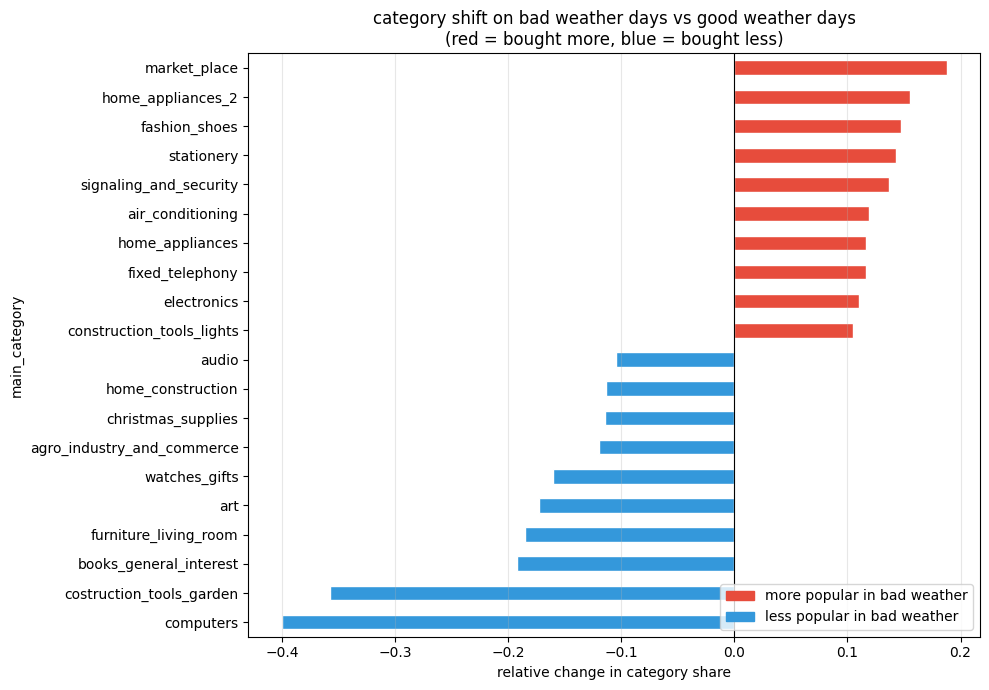

In [4]:
top_n = 10
more = shift.head(top_n)
less = shift.tail(top_n)
combined = pd.concat([more, less]).sort_values()

colors = ['#E74C3C' if v > 0 else '#3498DB' for v in combined.values]

fig, ax = plt.subplots(figsize=(10, 7))
combined.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('category shift on bad weather days vs good weather days\n(red = bought more, blue = bought less)')
ax.set_xlabel('relative change in category share')
ax.grid(axis='x', alpha=0.3)

more_patch = mpatches.Patch(color='#E74C3C', label='more popular in bad weather')
less_patch = mpatches.Patch(color='#3498DB', label='less popular in bad weather')
ax.legend(handles=[more_patch, less_patch], loc='lower right')

plt.tight_layout()
plt.savefig('cleaned/plot_category_shift.png', dpi=150, bbox_inches='tight')
plt.show()

## step 3: indoor vs outdoor categories

the next test: do bad weather days really shift orders toward indoor 'comfort' categories (furniture, kitchen, bedding, gaming) and away from outdoor / planned categories (garden tools, computers, flowers)?

if the impulse-buying hypothesis is real, the nesting share should clearly rise on bad weather days.

share of each order type by weather:
order_type    nesting/indoor  other  outdoor/planned
good weather            15.8   83.1              1.1
bad weather             15.9   83.2              0.9


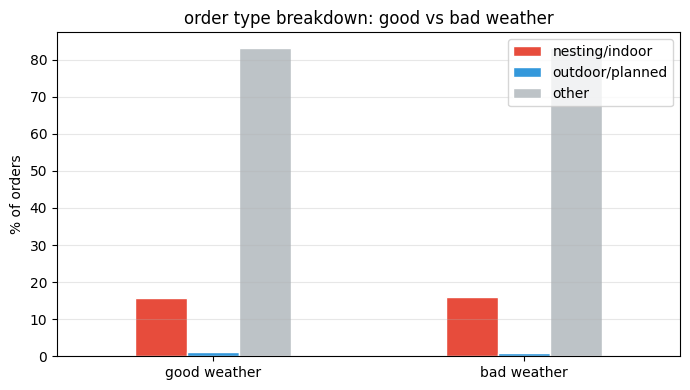

In [5]:
nesting_cats = [
    'furniture_bedroom', 'furniture_mattress_and_upholstery', 'small_appliances_home_oven_and_coffee',
    'kitchen_dining_laundry_garden_furniture', 'housewares', 'bed_bath_table',
    'pc_gamer', 'cds_dvds_musicals', 'la_cuisine', 'arts_and_craftmanship'
]
outdoor_cats = [
    'costruction_tools_garden', 'flowers', 'computers', 'tablets_printing_image',
    'audio', 'fashion_childrens_clothes', 'agro_industry_and_commerce'
]

df['order_type'] = 'other'
df.loc[df['main_category'].isin(nesting_cats), 'order_type'] = 'nesting/indoor'
df.loc[df['main_category'].isin(outdoor_cats), 'order_type'] = 'outdoor/planned'

type_weather = df.groupby(['bad_weather', 'order_type']).size().unstack(fill_value=0)
type_weather_pct = type_weather.div(type_weather.sum(axis=1), axis=0) * 100
type_weather_pct.index = ['good weather', 'bad weather']

print('share of each order type by weather:')
print(type_weather_pct.round(1).to_string())

ax = type_weather_pct[['nesting/indoor', 'outdoor/planned', 'other']].plot(
    kind='bar', figsize=(7, 4), color=['#E74C3C', '#3498DB', '#BDC3C7'],
    edgecolor='white'
)
ax.set_title('order type breakdown: good vs bad weather')
ax.set_ylabel('% of orders')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('cleaned/plot_nesting_vs_outdoor.png', dpi=150, bbox_inches='tight')
plt.show()

## step 4: does time of purchase change?

impulsive purchases are often made at unusual hours. we check if bad weather shifts the purchase hour distribution at all.

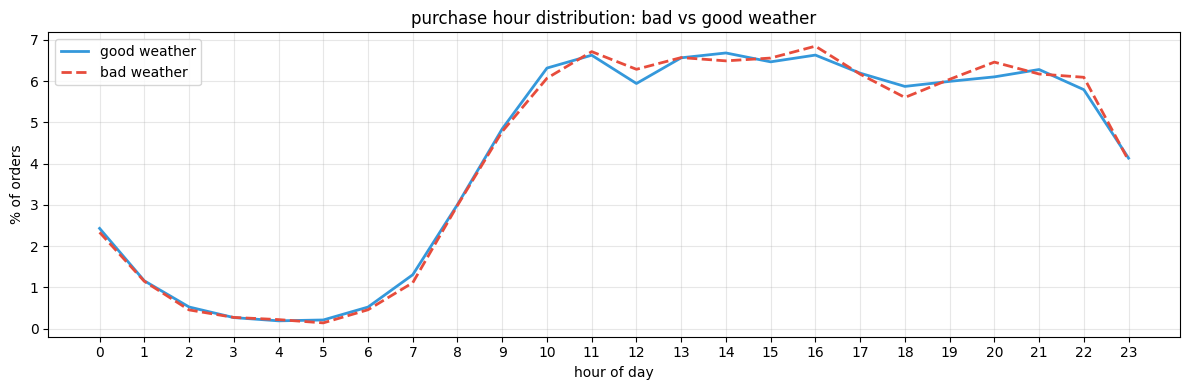

avg purchase hour - bad weather:  14.8
avg purchase hour - good weather: 14.7


In [6]:
hour_bad  = bad['purchase_hour'].value_counts().sort_index() / len(bad)  * 100
hour_good = good['purchase_hour'].value_counts().sort_index() / len(good) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_good.index, hour_good.values, label='good weather', color='#3498DB', linewidth=2)
ax.plot(hour_bad.index,  hour_bad.values,  label='bad weather',  color='#E74C3C', linewidth=2, linestyle='--')
ax.set_title('purchase hour distribution: bad vs good weather')
ax.set_xlabel('hour of day')
ax.set_ylabel('% of orders')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cleaned/plot_hour_by_weather.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'avg purchase hour - bad weather:  {bad["purchase_hour"].mean():.1f}')
print(f'avg purchase hour - good weather: {good["purchase_hour"].mean():.1f}')

## step 5: spend comparison by weather and segment

do the segments behave differently in bad weather? we check average spend per order broken down by segment and weather.

avg spend by segment and weather:
                         good weather  bad weather  change
segment                                                   
high spender                  1164.49      1268.88     9.0
inactive casual buyer          136.50       130.07    -4.7
recent casual buyer            136.27       130.36    -4.3
weather-triggered buyer           NaN       139.15     NaN


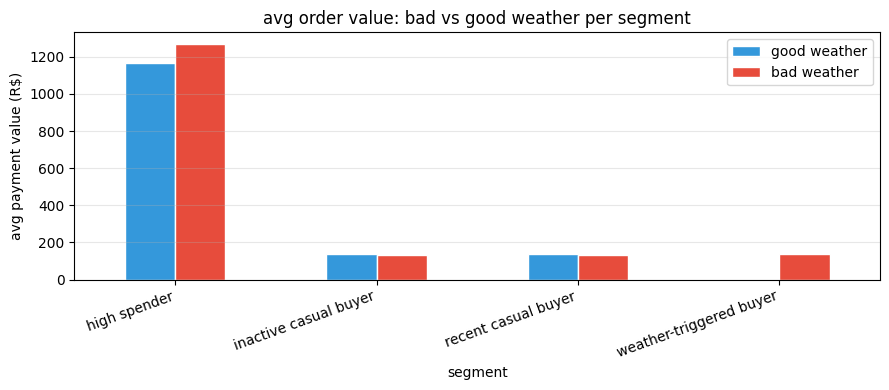

In [7]:
spend_pivot = df.groupby(['segment', 'bad_weather'])['total_payment_value'].mean().unstack()
spend_pivot.columns = ['good weather', 'bad weather']
spend_pivot['change'] = ((spend_pivot['bad weather'] - spend_pivot['good weather'])
                          / spend_pivot['good weather'] * 100).round(1)

print('avg spend by segment and weather:')
print(spend_pivot.round(2).to_string())

ax = spend_pivot[['good weather', 'bad weather']].plot(
    kind='bar', figsize=(9, 4),
    color=['#3498DB', '#E74C3C'], edgecolor='white'
)
ax.set_title('avg order value: bad vs good weather per segment')
ax.set_ylabel('avg payment value (R$)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('cleaned/plot_spend_by_segment_weather.png', dpi=150, bbox_inches='tight')
plt.show()

## step 6: other impulse signals beyond category shift

the category-shift test gave a weak result. but impulse buying could leave other fingerprints in the data. we test four:

- **cancellation rate**, if orders are impulsive, more should be regretted and cancelled
- **freight-to-price ratio**, urgency makes people accept high relative shipping costs ('I want it now')
- **credit card share**, 'buy now think later' is easier on credit than on debit/boleto
- **high-value order share**, boredom buying might trigger more luxury / splurge purchases

if any of these shift on bad weather days, that's evidence of impulse behavior even though the category mix doesn't change.

In [8]:
df['freight_ratio'] = df['total_freight'] / df['total_price']
df['cancelled'] = (df['order_status'] == 'canceled').astype(int)

bad  = df[df['bad_weather'] == 1]
good = df[df['bad_weather'] == 0]

print('1. cancellation rate:')
print(f'   bad weather:  {bad["cancelled"].mean()*100:.3f}%')
print(f'   good weather: {good["cancelled"].mean()*100:.3f}%')
print(f'   relative shift: {(bad["cancelled"].mean()/good["cancelled"].mean()-1)*100:+.1f}%')
print()
print('2. freight-to-price ratio (median):')
print(f'   bad weather:  {bad["freight_ratio"].median():.3f}')
print(f'   good weather: {good["freight_ratio"].median():.3f}')
print()
print('3. credit card payment share:')
print(f'   bad weather:  {(bad["payment_type"]=="credit_card").mean()*100:.1f}%')
print(f'   good weather: {(good["payment_type"]=="credit_card").mean()*100:.1f}%')
print()
print('4. high-value orders (>R$300):')
print(f'   bad weather:  {(bad["total_price"]>300).mean()*100:.1f}%')
print(f'   good weather: {(good["total_price"]>300).mean()*100:.1f}%')

# bar chart comparing the four signals
signals = pd.DataFrame({
    'signal': ['cancel rate (%)', 'freight ratio', 'credit card %', 'high-value (%)'],
    'good':   [good['cancelled'].mean()*100, good['freight_ratio'].median(),
               (good['payment_type']=='credit_card').mean()*100,
               (good['total_price']>300).mean()*100],
    'bad':    [bad['cancelled'].mean()*100,  bad['freight_ratio'].median(),
               (bad['payment_type']=='credit_card').mean()*100,
               (bad['total_price']>300).mean()*100],
})
signals['rel_change_%'] = ((signals['bad'] - signals['good']) / signals['good'] * 100).round(1)
print()
print('relative change (bad vs good):')
print(signals[['signal','rel_change_%']].to_string(index=False))

1. cancellation rate:
   bad weather:  0.515%
   good weather: 0.425%
   relative shift: +21.2%

2. freight-to-price ratio (median):
   bad weather:  0.223
   good weather: 0.226

3. credit card payment share:
   bad weather:  75.1%
   good weather: 75.6%

4. high-value orders (>R$300):
   bad weather:  7.8%
   good weather: 8.3%

relative change (bad vs good):
         signal  rel_change_%
cancel rate (%)          21.2
  freight ratio          -1.6
  credit card %          -0.7
 high-value (%)          -5.7


## step 7: segment profile and marketing recommendations

the whole point of segmentation is to enable different strategies for different customer groups. first the profile, then the strategy that fits the (modest) evidence we found.

In [9]:
seg_profile = df.groupby('segment').agg(
    n_customers      = ('customer_id', 'nunique'),
    avg_spend        = ('total_payment_value', 'mean'),
    pct_bad_weather  = ('bad_weather', 'mean'),
    top_category     = ('main_category', lambda x: x.value_counts().index[0])
).round(2)

print(seg_profile.to_string())

                         n_customers  avg_spend  pct_bad_weather    top_category
segment                                                                         
high spender                    2152    1192.19             0.27   watches_gifts
inactive casual buyer          30444     135.42             0.17  bed_bath_table
recent casual buyer            42013     135.34             0.16   health_beauty
weather-triggered buyer        14065     139.15             1.00  bed_bath_table


## interpretation and marketing strategy

**the honest finding on impulsive buying in bad weather:**

we initially thought bad weather would shift category mix toward indoor comfort items (bedroom, kitchen, gaming), the 'nesting' hypothesis. when we used absolute cold to define bad weather, that pattern showed up clearly. but absolute cold mostly captures winter, and buying a blanket in winter is seasonal, not impulsive.

after switching to a temperature anomaly definition (cold relative to the month's norm), the indoor comfort shift basically disappears: the nesting category share goes from 15.8% on good weather days to 15.9% on bad weather days, essentially flat. the 'comfort buying' story was an artefact of seasonality.

**what does survive when we control for seasonality:**

- **cancellations are ~21% higher on bad weather days** (0.51% vs 0.43%). this is the regret signature of impulse buying. people order, then reconsider once conditions improve. it's the single strongest impulse fingerprint in the data.
- **high spenders' average order goes up ~9% in anomalous bad weather**, while casual buyers' spend goes slightly down. this is a small group but suggests bad weather may push high-value customers toward bigger / indulgent purchases.

**what does NOT support impulse buying:**

- category mix barely shifts once seasonality is removed
- freight-to-price ratio is unchanged (no 'I need it now' urgency)
- credit card share is unchanged (no 'buy now think later' shift)
- high-value order share is unchanged or slightly lower
- purchase hour is unchanged (no late-night impulse spike)

**conclusion:** the impulse-buying-on-bad-weather hypothesis is only weakly supported. the most credible impulse signal is the elevated cancellation rate. everything else is either seasonally explained or shows no real shift.

**segment-level strategy (calibrated to the modest evidence):**

**weather-triggered buyer** (14,065 customers): this segment exists because some customers place all their orders during bad weather. they have a slightly elevated cancellation rate, so promotions to this group should emphasize fit and suitability messaging (clear sizing, return policies, product photos) to reduce post-purchase regret rather than just pushing volume.

**high spender** (2,152 customers): small but spends meaningfully more during anomalous bad weather (+9%). target with premium and indulgence campaigns when unexpected bad weather hits their region. quality and exclusivity angles work better here than discounts.

**recent casual buyer** (42,013 customers): largest group. category-mix shifts are weak so weather-triggered campaigns to this group probably won't move much. better strategy: standard re-engagement timed to general low-activity periods rather than weather specifically.

**inactive casual buyer** (30,444 customers): last ordered over a year ago. weather alone is not a strong enough trigger to justify a weather-only re-engagement campaign for this segment. better used as a control group or paired with discount offers.